In [1]:
import pandas as pd

data = {
    "CustomerID": [1,2,3,4,5,6,7],
    "Age": [22,35,45,25,50,23,40],
    "MonthlyCharges": [2000,3000,4000,2500,5000,2200,3800],
    "Contract": ["Monthly","Yearly","Monthly","Monthly","Yearly","Monthly","Yearly"],
    "Churn": ["Yes","No","Yes","No","No","Yes","No"]
}

df = pd.DataFrame(data)
print(df)

   CustomerID  Age  MonthlyCharges Contract Churn
0           1   22            2000  Monthly   Yes
1           2   35            3000   Yearly    No
2           3   45            4000  Monthly   Yes
3           4   25            2500  Monthly    No
4           5   50            5000   Yearly    No
5           6   23            2200  Monthly   Yes
6           7   40            3800   Yearly    No


In [3]:
# churn count
print(df["Churn"].value_counts())

# avg charges of churn customers
print(df[df["Churn"]=="Yes"]["MonthlyCharges"].mean())

# contract vs churn
print(pd.crosstab(df["Contract"], df["Churn"]))

Churn
No     4
Yes    3
Name: count, dtype: int64
2733.3333333333335
Churn     No  Yes
Contract         
Monthly    1    3
Yearly     3    0


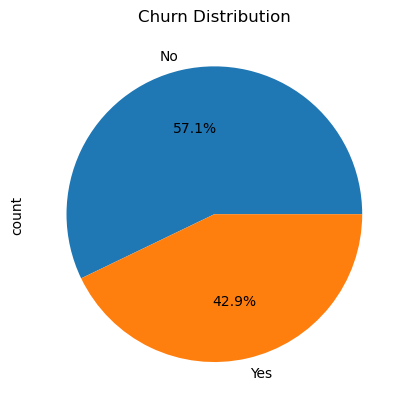

In [5]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.show()

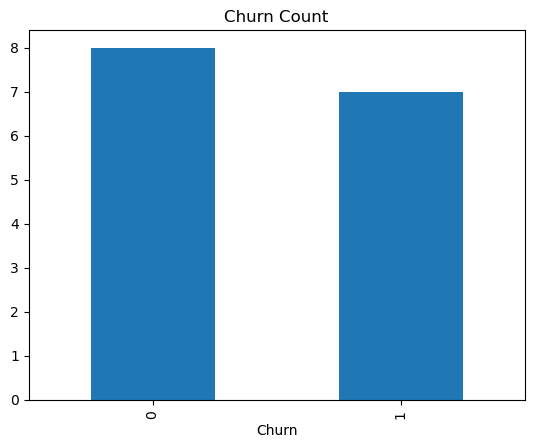

Accuracy: 0.6666666666666666
Confusion Matrix:
 [[0 1]
 [0 2]]


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 1: Bigger dataset
data = {
    "Age": [22,35,45,25,50,23,40,36,29,48,33,41,27,39,30],
    "MonthlyCharges": [2000,3000,4000,2500,5000,2200,3800,3200,2700,4500,3100,3900,2600,3500,2800],
    "Contract": ["Monthly","Yearly","Monthly","Monthly","Yearly","Monthly","Yearly","Monthly","Monthly","Yearly","Monthly","Yearly","Monthly","Yearly","Monthly"],
    "Churn": ["Yes","No","Yes","No","No","Yes","No","Yes","No","No","Yes","No","Yes","No","Yes"]
}

df = pd.DataFrame(data)

# Step 2: Encoding
df["Contract"] = df["Contract"].map({"Monthly":0, "Yearly":1})
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

# Step 3: Visualization (IMPORTANT 🔥)
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Count")
plt.show()

# Step 4: Features
X = df[["Age", "MonthlyCharges", "Contract"]]
y = df["Churn"]

# Step 5: Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 6: Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 7: Prediction
y_pred = model.predict(X_test)

# Step 8: Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Step 9: Confusion Matrix (ADVANCED 🔥)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

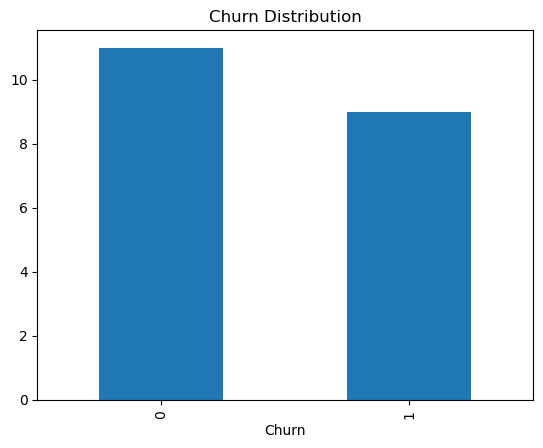

Logistic Regression Accuracy: 0.75
Decision Tree Accuracy: 0.75
Best Model: Decision Tree

Confusion Matrix (Logistic):
 [[2 0]
 [1 1]]

Confusion Matrix (Decision Tree):
 [[2 0]
 [1 1]]


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 1: Dataset
data = {
    "Age": [22,35,45,25,50,23,40,36,29,48,33,41,27,39,30,31,44,28,37,42],
    "MonthlyCharges": [2000,3000,4000,2500,5000,2200,3800,3200,2700,4500,3100,3900,2600,3500,2800,3000,4200,2900,3600,4100],
    "Contract": ["Monthly","Yearly","Monthly","Monthly","Yearly","Monthly","Yearly","Monthly","Monthly","Yearly","Monthly","Yearly","Monthly","Yearly","Monthly","Monthly","Yearly","Monthly","Yearly","Monthly"],
    "Churn": ["Yes","No","Yes","No","No","Yes","No","Yes","No","No","Yes","No","Yes","No","Yes","Yes","No","Yes","No","No"]
}

df = pd.DataFrame(data)

# Step 2: Encoding
df["Contract"] = df["Contract"].map({"Monthly":0, "Yearly":1})
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

# Step 3: Visualization
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

# Step 4: Features
X = df[["Age", "MonthlyCharges", "Contract"]]
y = df["Churn"]

# Step 5: Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# -------------------------------
# Model 1: Logistic Regression
# -------------------------------
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

# -------------------------------
# Model 2: Decision Tree
# -------------------------------
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

# -------------------------------
# Results
# -------------------------------
print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)

# Best Model
if lr_acc > dt_acc:
    print("Best Model: Logistic Regression")
else:
    print("Best Model: Decision Tree")

# Confusion Matrix
print("\nConfusion Matrix (Logistic):\n", confusion_matrix(y_test, lr_pred))
print("\nConfusion Matrix (Decision Tree):\n", confusion_matrix(y_test, dt_pred))